In [333]:
# All imports
import pandas as pd
from Classes import FileManager as fm
from Classes.DataPlotter import DataPlotter
from Classes import Calculations as calc

# Folder with run data (e.g., SD card)
folder = r"Data"

# Get latest CSV file
latest_file = fm.get_latest_file(folder)
print(latest_file)

# Create plotter object for graphs
# plotter = DataPlotter(r"D:\d_71.csv")
plotter = DataPlotter(latest_file)

# plotter = DataPlotter(CSV_PATH)
plotter.load_data()

#Track Len
TRACK_LEN = 3832.5


Data/d_75.csv


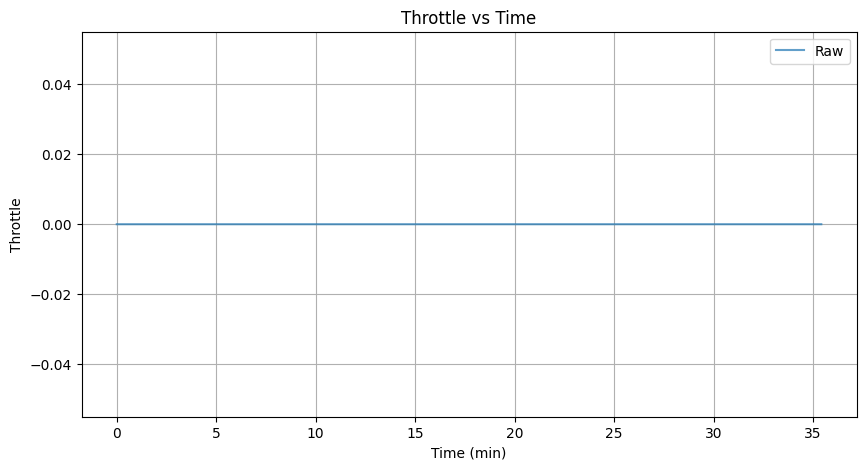

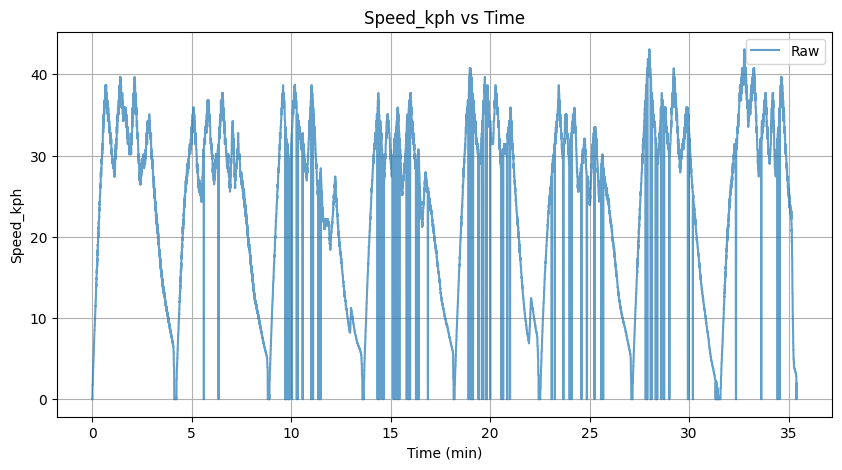

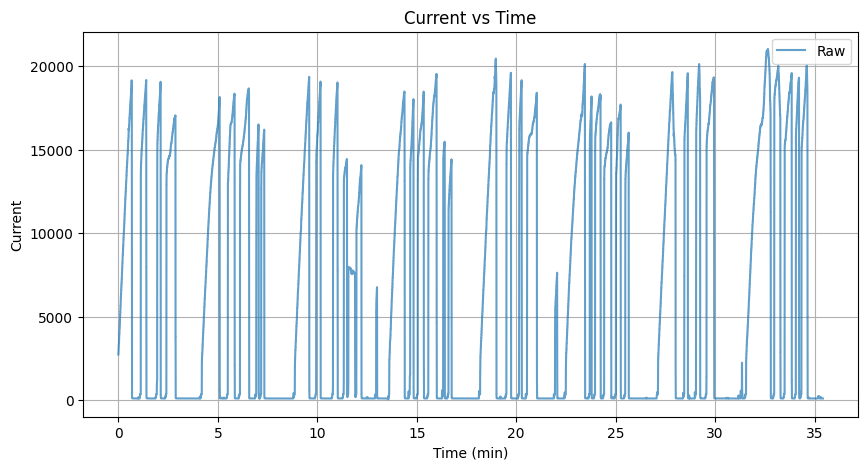

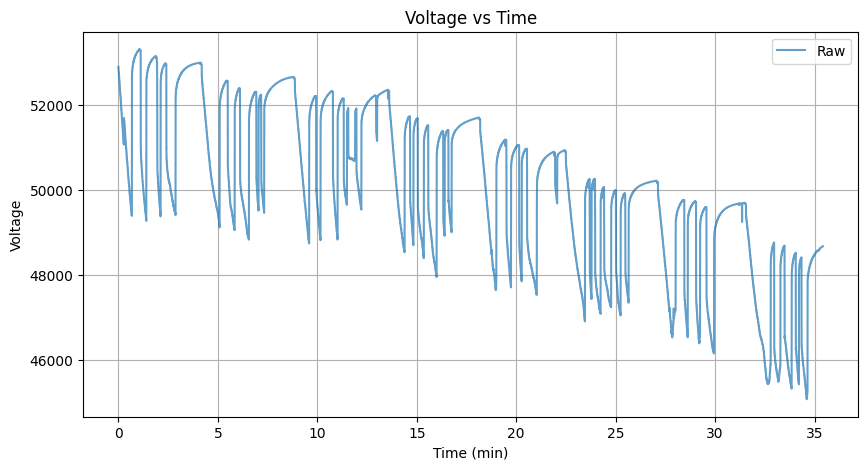

In [334]:
# Plot all columns
plotter.plot_all(smooth_window=0)

In [335]:
calc.get_efficiency(num_laps=2,energy_joules=267_844,track_len_km=TRACK_LEN)

Efficiency: 103022.65 km/kWh


In [336]:
calc.get_total_energy(plotter.data)


Total energy consumed: 644379.9977996114 J or 0.17899444383322538 kWh


# Track Map — IMS Grand Prix Road Course
Mapping **voltage**, **current draw**, and **car speed** onto the track layout.

| Parameter | Value |
|-----------|-------|
| Wheel diameter | 0.55 m |
| Encoder ticks/rev | 4 |
| Distance per tick | π × 0.55 / 4 ≈ 0.432 m |
| Track length | 3.875 km (15.5 / 4) |

In [337]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# ── Physical parameters ──
WHEEL_DIAM = 0.55  # m
N_ENC = 4
CIRCUMFERENCE = np.pi * WHEEL_DIAM          # 1.7279 m
DIST_PER_TICK = CIRCUMFERENCE / N_ENC       # 0.4320 m
TRACK_LEN = 3832.5                          # metres (15.5/4 km)
SPEED_SCALE = 1.06  # scaling factor applied to raw speed (tune to match known lap distance)
CHOP_SECONDS = 0   # drop the first N seconds of data (e.g. pre-start idle)
START_COORDS = (39.792255, -86.238697)  # (lat, lon) — track origin for TrackPos = 0

# ── Process telemetry ──
df = plotter.data.copy()

# Chop leading data
if CHOP_SECONDS > 0:
    chop_ms = CHOP_SECONDS * 1000
    df = df[df['Tick'] >= chop_ms].copy()
    df['Tick'] = df['Tick'] - df['Tick'].iloc[0]   # re-zero after chop
    df['TimePlot'] = df['Tick'] / 60_000            # recalc minutes

# Recompute speed with scaling factor (raw Speed * 0.001 = kph before scaling)
df['Speed_kph'] = df['Speed'] * 0.001 * SPEED_SCALE
df['Speed_mps'] = df['Speed_kph'] / 3.6
df['Voltage_V'] = df['Voltage'] / 1000.0    # mV -> V
df['Current_A'] = df['Current'] / 1000.0    # mA -> A
df['dt'] = df['Tick'].diff().fillna(0) / 1000.0   # ms -> s
df['Distance_m'] = np.cumsum(df['Speed_mps'].values * df['dt'].values)
# TrackPos computed below after GPS track is loaded (needs arc-length for START_COORDS offset)

total_dist = df['Distance_m'].iloc[-1]
n_laps = total_dist / TRACK_LEN
print(f"Wheel dia: {WHEEL_DIAM} m | Circumference: {CIRCUMFERENCE:.4f} m")
print(f"Encoder ticks/rev: {N_ENC} | Distance/tick: {DIST_PER_TICK:.4f} m")
print(f"Speed scale: {SPEED_SCALE}")
if CHOP_SECONDS > 0:
    print(f"Chopped first {CHOP_SECONDS}s — {len(plotter.data) - len(df)} samples removed")
print(f"Total distance: {total_dist:.0f} m ({total_dist/1000:.2f} km)")
print(f"Laps completed: {n_laps:.2f}")
print(f"Max speed: {df['Speed_kph'].max():.1f} kph | "
      f"Avg moving speed: {df.loc[df['Speed_kph'] > 1, 'Speed_kph'].mean():.1f} kph")
print(f"Voltage: {df['Voltage_V'].min():.1f} - {df['Voltage_V'].max():.1f} V | "
      f"Current: {df['Current_A'].min():.1f} - {df['Current_A'].max():.1f} A")

# ── Load real GPS track centreline ──
track_gps = pd.read_csv('sem-us-2022-track_coordinates.csv')
gps_lat = track_gps.Latitude.values
gps_lon = track_gps.Longitude.values

# Convert GPS -> local XY (metres)
lat_ref = gps_lat.mean()
lon_ref = gps_lon.mean()
m_per_deg_lat = 110_540
m_per_deg_lon = 111_320 * np.cos(np.radians(lat_ref))
track_x = (gps_lon - lon_ref) * m_per_deg_lon
track_y = (gps_lat - lat_ref) * m_per_deg_lat
track_xy = np.column_stack([track_x, track_y])

# Arc-length along the GPS centreline
seg_lens = np.sqrt(np.sum(np.diff(track_xy, axis=0)**2, axis=1))
arc = np.zeros(len(track_xy))
arc[1:] = np.cumsum(seg_lens)
total_arc = arc[-1]

# ── Compute TrackPos with start-coordinate offset ──
_dists_to_start = (gps_lat - START_COORDS[0])**2 + (gps_lon - START_COORDS[1])**2
_start_idx = int(np.argmin(_dists_to_start))
_start_arc = arc[_start_idx]
START_OFFSET = (_start_arc / total_arc) * TRACK_LEN
df['TrackPos'] = (df['Distance_m'] + START_OFFSET) % TRACK_LEN
print(f"Start offset: {START_OFFSET:.1f} m (track point #{_start_idx}, "
      f"nearest to {START_COORDS})")

def dist_to_xy(d):
    """Map a track distance (m) to an (x, y) point on the GPS centreline."""
    arc_pos = (d / TRACK_LEN) * total_arc
    idx = min(np.searchsorted(arc, arc_pos % total_arc), len(track_xy) - 1)
    return track_xy[idx]

print(f"\nGPS track: {len(track_xy)} pts | arc = {total_arc:.0f} m")

Wheel dia: 0.55 m | Circumference: 1.7279 m
Encoder ticks/rev: 4 | Distance/tick: 0.4320 m
Speed scale: 1.06
Total distance: 15172 m (15.17 km)
Laps completed: 3.96
Max speed: 45.7 kph | Avg moving speed: 26.6 kph
Voltage: 45.1 - 53.3 V | Current: 0.1 - 21.0 A
Start offset: 28.9 m (track point #27, nearest to (39.792255, -86.238697))

GPS track: 3833 pts | arc = 3818 m


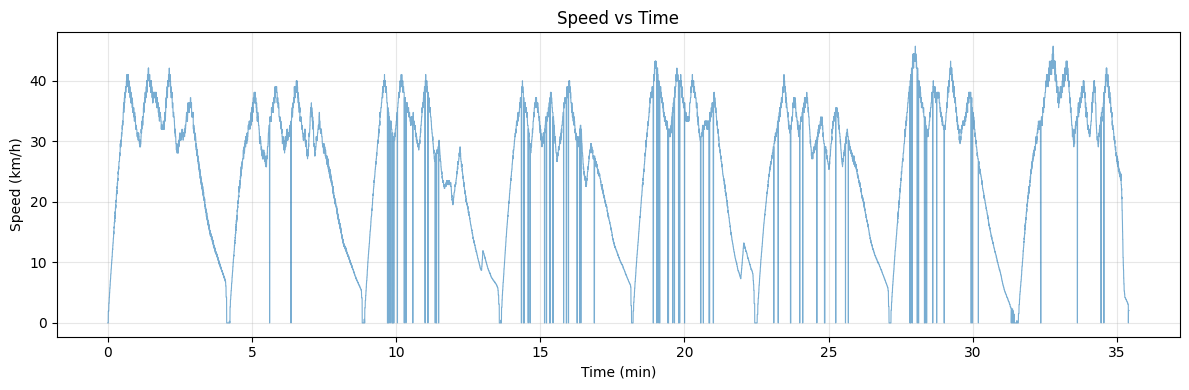

In [338]:
plt.figure(figsize=(12, 4))
plt.plot(df['TimePlot'], df['Speed_kph'], alpha=0.6, linewidth=0.8)
plt.xlabel('Time (min)')
plt.ylabel('Speed (km/h)')
plt.title('Speed vs Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Efficiency Analysis

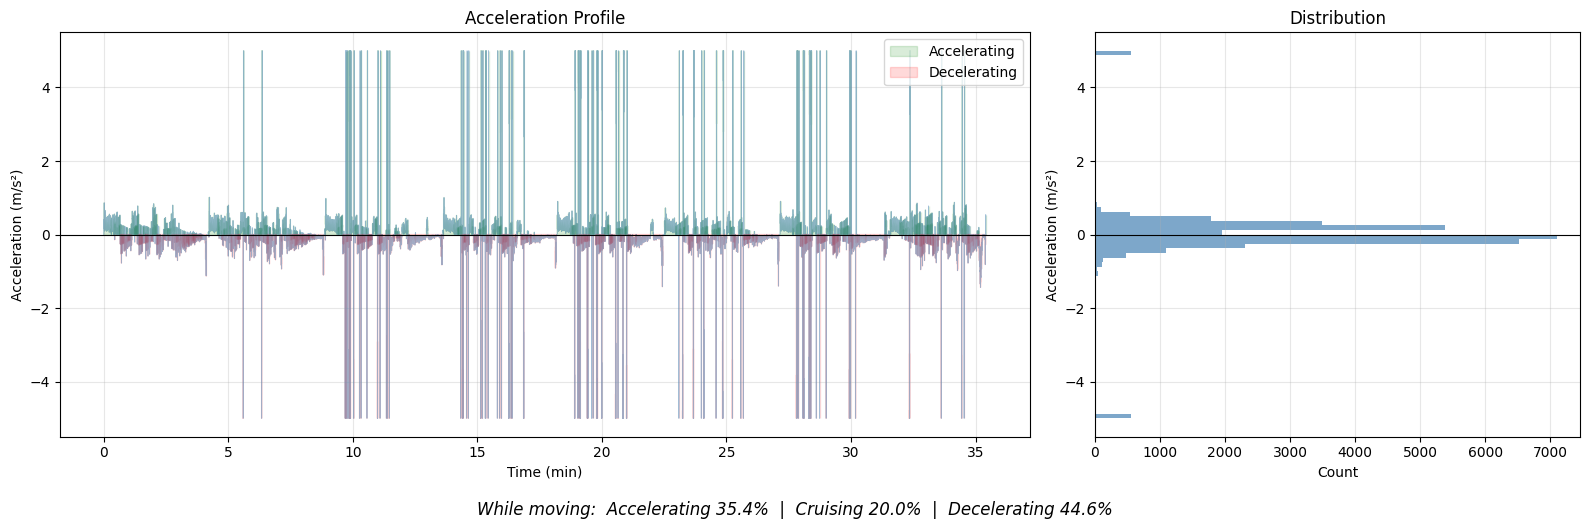

In [339]:
# ── Acceleration Profile ──
# Smooth speed to avoid amplifying sensor noise when differentiating
SMOOTH_W = 21  # rolling window size (odd number)
speed_smooth = df['Speed_mps'].rolling(SMOOTH_W, center=True, min_periods=1).mean()
accel = speed_smooth.diff() / df['dt']
accel = accel.fillna(0).clip(-5, 5)  # clip outliers from large dt gaps

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 1]})

# Left — acceleration vs time
ax = axes[0]
ax.plot(df['TimePlot'], accel, alpha=0.5, linewidth=0.6, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8)
ax.fill_between(df['TimePlot'], accel, 0,
                where=accel > 0, alpha=0.15, color='green', label='Accelerating')
ax.fill_between(df['TimePlot'], accel, 0,
                where=accel < 0, alpha=0.15, color='red', label='Decelerating')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Acceleration (m/s²)')
ax.set_title('Acceleration Profile')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Right — histogram + time-share breakdown
ax2 = axes[1]
ax2.hist(accel[accel != 0], bins=80, orientation='horizontal',
         color='steelblue', alpha=0.7, edgecolor='none')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Count')
ax2.set_ylabel('Acceleration (m/s²)')
ax2.set_title('Distribution')
ax2.grid(True, alpha=0.3)

# Time-share stats
moving = df['Speed_kph'] > 1  # ignore standstill
accel_moving = accel[moving]
t_accel = (accel_moving > 0.05).sum()
t_decel = (accel_moving < -0.05).sum()
t_cruise = ((accel_moving >= -0.05) & (accel_moving <= 0.05)).sum()
total = t_accel + t_decel + t_cruise
if total > 0:
    fig.text(0.5, -0.04,
             f'While moving:  Accelerating {t_accel/total*100:.1f}%  |  '
             f'Cruising {t_cruise/total*100:.1f}%  |  '
             f'Decelerating {t_decel/total*100:.1f}%',
             ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()

Cleaned dataset: 37168 → 35235 rows (1933 removed)


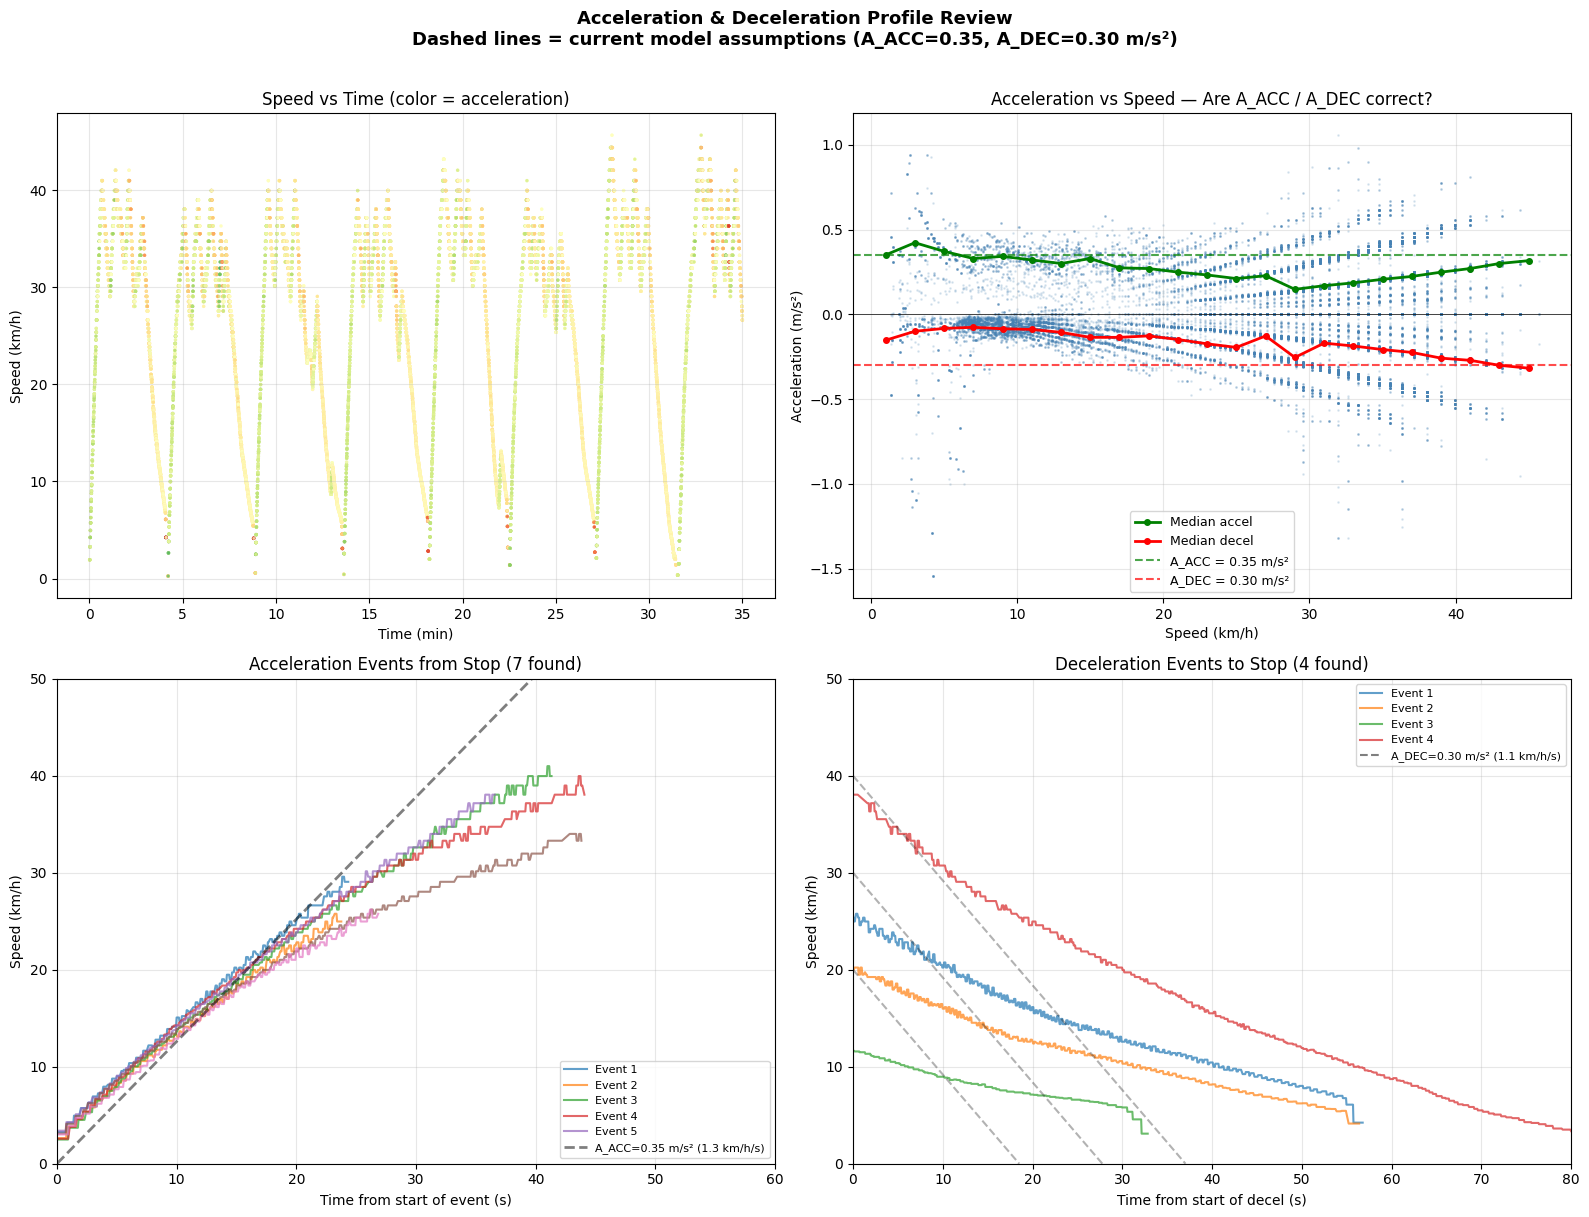

Acceleration (when > 0.05 m/s²):  mean=0.268  median=0.249  std=0.127
Deceleration (when < -0.05 m/s²): mean=-0.205  median=-0.169  std=0.141


In [340]:
# ── Acceleration & Deceleration Rate Review ──
# Verify A_ACC and A_DEC assumptions against telemetry

# ── Clean dataset: crop after 35 min, drop outliers ──
n_before = len(df)
df = df[df['TimePlot'] <= 35].copy()
df = df[df['Speed_kph'] > 0].copy()

# IQR outlier removal on speed
q1_s, q3_s = df['Speed_kph'].quantile(0.25), df['Speed_kph'].quantile(0.75)
iqr_s = q3_s - q1_s
df = df[df['Speed_kph'] <= q3_s + 1.5 * iqr_s].copy()

# Recompute dt and accel after row removal
df['dt'] = df['Tick'].diff().fillna(0) / 1000.0
SMOOTH_W = 21
speed_smooth = df['Speed_mps'].rolling(SMOOTH_W, center=True, min_periods=1).mean()
accel = speed_smooth.diff() / df['dt']
accel = accel.fillna(0).clip(-5, 5)

# IQR outlier removal on acceleration
q1_a, q3_a = accel.quantile(0.25), accel.quantile(0.75)
iqr_a = q3_a - q1_a
keep = (accel >= q1_a - 1.5 * iqr_a) & (accel <= q3_a + 1.5 * iqr_a)
df = df[keep].copy()
accel = accel[keep]

# Recompute dt and accel once more after accel-based removal
df['dt'] = df['Tick'].diff().fillna(0) / 1000.0
speed_smooth = df['Speed_mps'].rolling(SMOOTH_W, center=True, min_periods=1).mean()
accel = speed_smooth.diff() / df['dt']
accel = accel.fillna(0).clip(-5, 5)

print(f'Cleaned dataset: {n_before} → {len(df)} rows ({n_before - len(df)} removed)')

# ── Plots ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Top-left: Speed vs Time with accel/decel colored ──
ax = axes[0, 0]
ax.scatter(df['TimePlot'], df['Speed_kph'], c=accel, cmap='RdYlGn',
           vmin=-1.5, vmax=1.5, s=2, alpha=0.6)
ax.set_xlabel('Time (min)')
ax.set_ylabel('Speed (km/h)')
ax.set_title('Speed vs Time (color = acceleration)')
ax.grid(True, alpha=0.3)

# ── Top-right: Acceleration vs Speed scatter ──
ax = axes[0, 1]
moving = df['Speed_kph'] > 1
ax.scatter(df.loc[moving, 'Speed_kph'], accel[moving],
           s=1, alpha=0.15, color='steelblue', rasterized=True)

speed_bins = np.arange(0, df['Speed_kph'].max() + 2, 2)
speed_mids = (speed_bins[:-1] + speed_bins[1:]) / 2
bin_idx = np.digitize(df.loc[moving, 'Speed_kph'].values, speed_bins) - 1
accel_vals = accel[moving].values

med_acc, med_dec = [], []
for b in range(len(speed_mids)):
    mask = bin_idx == b
    a = accel_vals[mask]
    med_acc.append(np.median(a[a > 0.05]) if np.sum(a > 0.05) > 5 else np.nan)
    med_dec.append(np.median(a[a < -0.05]) if np.sum(a < -0.05) > 5 else np.nan)

ax.plot(speed_mids, med_acc, 'g-o', ms=4, lw=2, label='Median accel')
ax.plot(speed_mids, med_dec, 'r-o', ms=4, lw=2, label='Median decel')
ax.axhline(0.35, color='green', ls='--', alpha=0.7, label=f'A_ACC = 0.35 m/s²')
ax.axhline(-0.30, color='red', ls='--', alpha=0.7, label=f'A_DEC = 0.30 m/s²')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Acceleration (m/s²)')
ax.set_title('Acceleration vs Speed — Are A_ACC / A_DEC correct?')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Bottom-left: Individual acceleration events (0 → peak) ──
ax = axes[1, 0]
spd = df['Speed_kph'].values
tick_s = df['Tick'].values / 1000.0

in_accel = False
events_acc = []
for idx in range(1, len(spd)):
    if not in_accel and spd[idx-1] < 2 and spd[idx] >= 2:
        start_idx = idx
        in_accel = True
    elif in_accel:
        if accel.iloc[idx] < 0 or spd[idx] >= spd[idx-1] * 0.95 - 0.5:
            pass
        if accel.iloc[idx] < -0.1 and idx - start_idx > 5:
            events_acc.append((start_idx, idx))
            in_accel = False

for i, (s, e) in enumerate(events_acc[:15]):
    t_ev = tick_s[s:e] - tick_s[s]
    v_ev = spd[s:e]
    ax.plot(t_ev, v_ev, alpha=0.7, lw=1.5, label=f'Event {i+1}' if i < 5 else None)

t_ref = np.linspace(0, 60, 100)
ax.plot(t_ref, 0.35 * t_ref * 3.6, 'k--', lw=2, alpha=0.5,
        label=f'A_ACC=0.35 m/s² ({0.35*3.6:.1f} km/h/s)')
ax.set_xlabel('Time from start of event (s)')
ax.set_ylabel('Speed (km/h)')
ax.set_title(f'Acceleration Events from Stop ({len(events_acc)} found)')
ax.set_xlim(0, 60)
ax.set_ylim(0, 50)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

# ── Bottom-right: Individual deceleration events (coast to stop) ──
ax = axes[1, 1]
in_decel = False
events_dec = []
for idx in range(1, len(spd)):
    if not in_decel and spd[idx-1] > 10 and accel.iloc[idx] < -0.05:
        start_idx = idx
        in_decel = True
    elif in_decel:
        if spd[idx] < 1:
            events_dec.append((start_idx, idx))
            in_decel = False
        elif accel.iloc[idx] > 0.1:
            in_decel = False

for i, (s, e) in enumerate(events_dec[:15]):
    t_ev = tick_s[s:e] - tick_s[s]
    v_ev = spd[s:e]
    ax.plot(t_ev, v_ev, alpha=0.7, lw=1.5, label=f'Event {i+1}' if i < 5 else None)

for v0 in [20, 30, 40]:
    t_ref = np.linspace(0, v0/3.6/0.30, 100)
    v_ref = v0 - 0.30 * t_ref * 3.6
    ax.plot(t_ref, v_ref, 'k--', lw=1.5, alpha=0.3)
ax.plot([], [], 'k--', lw=1.5, alpha=0.5, label=f'A_DEC=0.30 m/s² ({0.30*3.6:.1f} km/h/s)')

ax.set_xlabel('Time from start of decel (s)')
ax.set_ylabel('Speed (km/h)')
ax.set_title(f'Deceleration Events to Stop ({len(events_dec)} found)')
ax.set_xlim(0, 80)
ax.set_ylim(0, 50)
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

plt.suptitle('Acceleration & Deceleration Profile Review\n'
             'Dashed lines = current model assumptions (A_ACC=0.35, A_DEC=0.30 m/s²)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print summary stats
a_pos = accel[moving & (accel > 0.05)]
a_neg = accel[moving & (accel < -0.05)]
print(f'Acceleration (when > 0.05 m/s²):  mean={a_pos.mean():.3f}  median={a_pos.median():.3f}  std={a_pos.std():.3f}')
print(f'Deceleration (when < -0.05 m/s²): mean={a_neg.mean():.3f}  median={a_neg.median():.3f}  std={a_neg.std():.3f}')

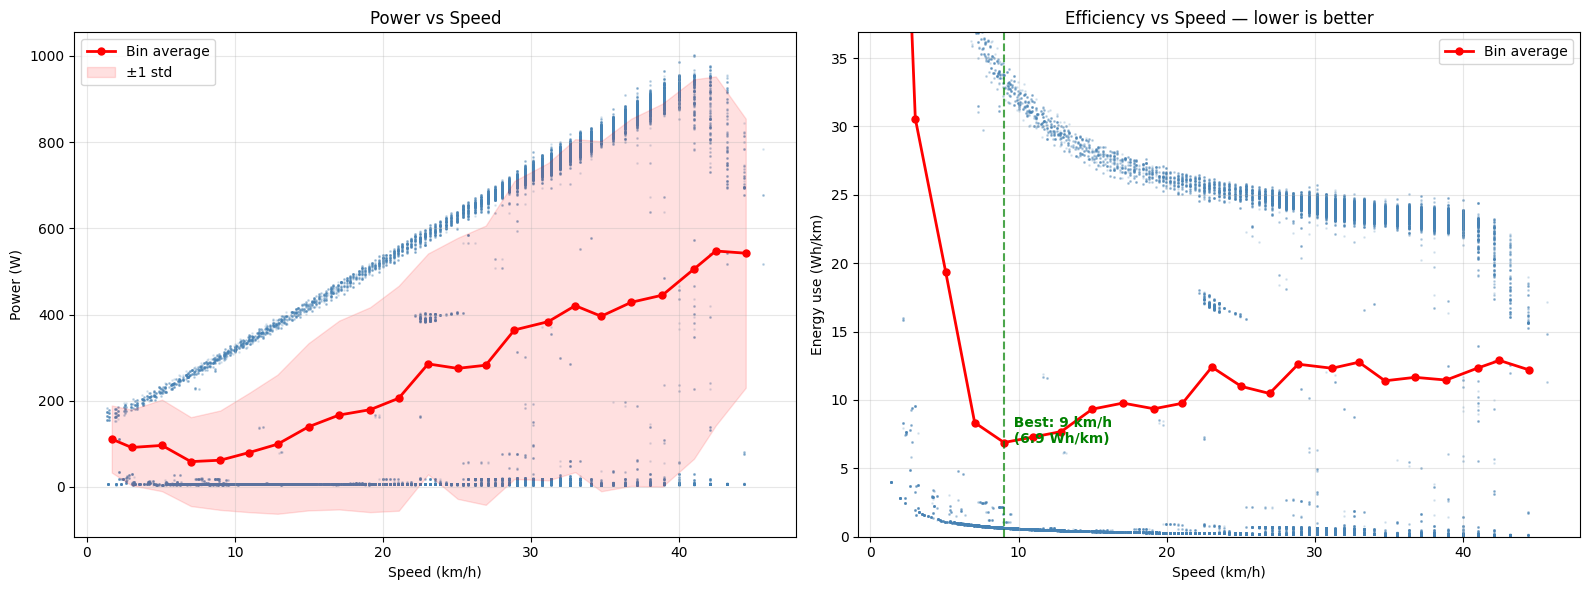

In [341]:
# ── Power vs Speed Scatter ──
df['Power_W'] = df['Voltage_V'] * df['Current_A']

# Filter to moving samples only
mask = df['Speed_kph'] > 1
spd_mov = df.loc[mask, 'Speed_kph']
pwr_mov = df.loc[mask, 'Power_W']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — raw scatter with binned average curve
ax = axes[0]
ax.scatter(spd_mov, pwr_mov, s=1, alpha=0.15, color='steelblue', rasterized=True)

# Bin averages to show the trend (drag curve)
speed_bins = np.arange(0, spd_mov.max() + 2, 2)  # 2 kph bins
bin_idx = np.digitize(spd_mov, speed_bins) - 1
bin_means = pd.DataFrame({'spd': spd_mov, 'pwr': pwr_mov, 'bin': bin_idx}) \
              .groupby('bin').agg(spd_mean=('spd', 'mean'), pwr_mean=('pwr', 'mean'),
                                  pwr_std=('pwr', 'std'), count=('pwr', 'count'))
bin_means = bin_means[bin_means['count'] >= 10]  # require enough samples
ax.plot(bin_means['spd_mean'], bin_means['pwr_mean'],
        'o-', color='red', linewidth=2, markersize=5, label='Bin average')
ax.fill_between(bin_means['spd_mean'],
                bin_means['pwr_mean'] - bin_means['pwr_std'],
                bin_means['pwr_mean'] + bin_means['pwr_std'],
                color='red', alpha=0.12, label='±1 std')
ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Power (W)')
ax.set_title('Power vs Speed')
ax.legend()
ax.grid(True, alpha=0.3)

# Right — Wh/km vs speed (instantaneous efficiency)
# Wh/km = Power_W / (Speed_m/s * 1000) * 1000  =  P / (v * 1000) * 1000  =  P / v
# More precisely: Wh/km = (W) / (km/h) = W·h/km
# Energy rate = P (W = J/s), distance rate = v (km/h = km/3600s)
# Wh/km = P / (v/3.6) / 1000  ... let's just compute it carefully:
# Wh/km = P(W) / v(m/s) / 1000   (since W/(m/s) = J/m, / 1000 = J/mm ... no)
# Wh/km = P(W) / (v(km/h)) * 1  since P is J/s and v is km/3600s:
#   energy per km = P / (v/3.6) J/m  = P*3.6/v J/m  * 1000 = P*3600/v J/km  / 3600 = P/v Wh/km
whpkm = pwr_mov / spd_mov  # Wh/km
ax2 = axes[1]
ax2.scatter(spd_mov, whpkm, s=1, alpha=0.15, color='steelblue', rasterized=True)

# Bin averages
bin_eff = pd.DataFrame({'spd': spd_mov, 'eff': whpkm, 'bin': bin_idx}) \
            .groupby('bin').agg(spd_mean=('spd', 'mean'), eff_mean=('eff', 'mean'),
                                count=('eff', 'count'))
bin_eff = bin_eff[bin_eff['count'] >= 10]
ax2.plot(bin_eff['spd_mean'], bin_eff['eff_mean'],
         'o-', color='red', linewidth=2, markersize=5, label='Bin average')

# Mark the optimal speed (minimum Wh/km)
if len(bin_eff) > 0:
    best = bin_eff.loc[bin_eff['eff_mean'].idxmin()]
    ax2.axvline(best['spd_mean'], color='green', linestyle='--', alpha=0.7)
    ax2.annotate(f"  Best: {best['spd_mean']:.0f} km/h\n  ({best['eff_mean']:.1f} Wh/km)",
                 xy=(best['spd_mean'], best['eff_mean']),
                 fontsize=10, fontweight='bold', color='green')

ax2.set_xlabel('Speed (km/h)')
ax2.set_ylabel('Energy use (Wh/km)')
ax2.set_title('Efficiency vs Speed — lower is better')
ax2.set_ylim(0, np.percentile(whpkm, 95) * 1.3)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Lap-by-lap speed stats (while moving):
 Lap  Avg (kph)  Std (kph)  CV (%)  Min (kph)  Max (kph)
   1       27.7        9.4    34.1        1.9       42.1
   2       24.2       10.7    44.3        2.0       41.0
   3       26.2       10.4    39.8        1.4       43.2

A lower CV% means steadier speed → less energy wasted on drag variation.


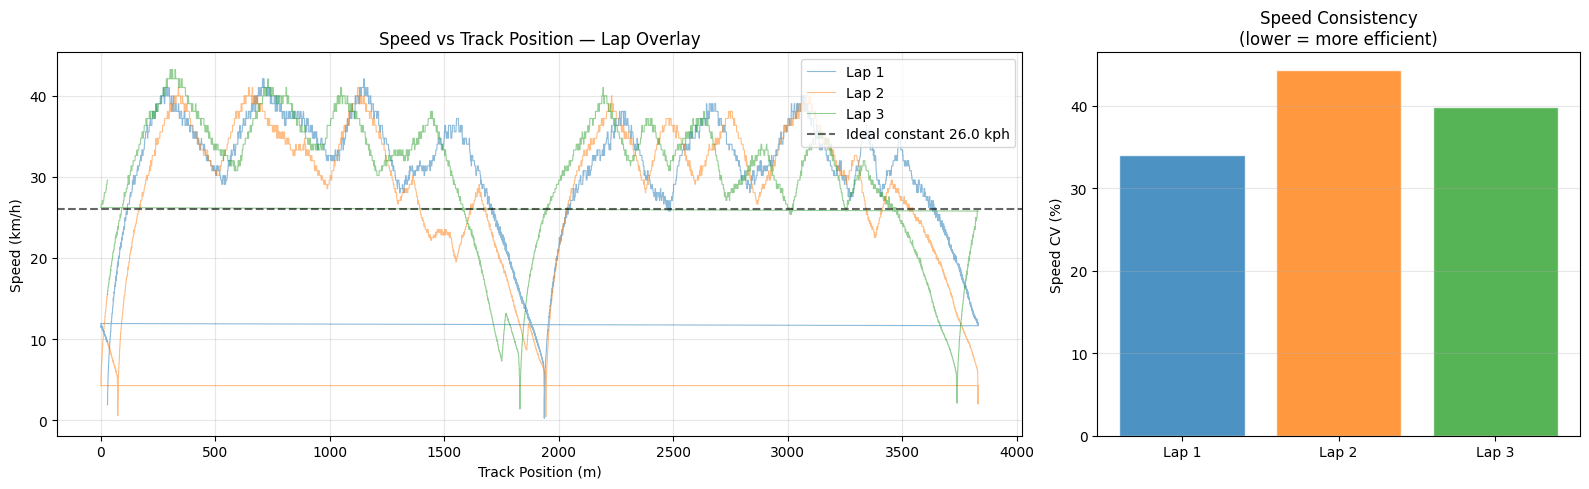

In [342]:
# ── Speed Variance per Lap ──
df['Lap'] = (df['Distance_m'] / TRACK_LEN).astype(int)
completed_laps = [l for l in df['Lap'].unique() if l < df['Lap'].max()]  # exclude partial last lap

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 1]})

# Left — speed vs track position, one trace per lap
ax = axes[0]
colors = plt.cm.tab10.colors
stats_rows = []

for j, lap_num in enumerate(completed_laps):
    lap_df = df[df['Lap'] == lap_num]
    pos = lap_df['TrackPos']
    spd = lap_df['Speed_kph']
    c = colors[j % len(colors)]
    ax.plot(pos, spd, alpha=0.5, linewidth=0.8, color=c, label=f'Lap {lap_num + 1}')

    # Compute stats for this lap
    moving = spd[spd > 1]
    stats_rows.append({
        'Lap': lap_num + 1,
        'Avg (kph)': moving.mean(),
        'Std (kph)': moving.std(),
        'CV (%)': moving.std() / moving.mean() * 100 if moving.mean() > 0 else 0,
        'Min (kph)': moving.min() if len(moving) > 0 else 0,
        'Max (kph)': moving.max() if len(moving) > 0 else 0,
    })

# Ideal constant-speed reference
if stats_rows:
    avg_all = np.mean([r['Avg (kph)'] for r in stats_rows])
    ax.axhline(avg_all, color='black', linestyle='--', linewidth=1.5,
               alpha=0.6, label=f'Ideal constant {avg_all:.1f} kph')

ax.set_xlabel('Track Position (m)')
ax.set_ylabel('Speed (km/h)')
ax.set_title('Speed vs Track Position — Lap Overlay')
ax.legend()
ax.grid(True, alpha=0.3)

# Right — bar chart of coefficient of variation per lap
ax2 = axes[1]
if stats_rows:
    lap_labels = [f'Lap {r["Lap"]}' for r in stats_rows]
    cvs = [r['CV (%)'] for r in stats_rows]
    bar_colors = [colors[j % len(colors)] for j in range(len(stats_rows))]
    bars = ax2.bar(lap_labels, cvs, color=bar_colors, alpha=0.8, edgecolor='white')
    ax2.set_ylabel('Speed CV (%)')
    ax2.set_title('Speed Consistency\n(lower = more efficient)')
    ax2.grid(True, alpha=0.3, axis='y')

    # Print stats table
    stats_df = pd.DataFrame(stats_rows).round(1)
    print("Lap-by-lap speed stats (while moving):")
    print(stats_df.to_string(index=False))
    print(f"\nA lower CV% means steadier speed → less energy wasted on drag variation.")

plt.tight_layout()
plt.show()

# Energy-Optimal Driving Strategy
Simplified model: no aero drag, no rolling resistance, no regenerative braking.  
Motor energy = kinetic energy (acceleration) + potential energy (uphill climbs).

Elevation mapped: 219.00 – 222.74 m (range 3.74 m)
Grade range: -2.69% to 2.29%
Mass: 164.0 kg
Accel phase 1 (0–15s): 0.2556 m/s² (0.92 km/h/s)
Accel phase 2 (15s+):  0.1944 m/s² (0.70 km/h/s)
Coast decel model: a = 0.0877 + 0.001970·v²  (fit from 15471 coast pts)
  at 20 km/h: 0.1485 m/s² (0.53 km/h/s)
  at 35 km/h: 0.2739 m/s² (0.99 km/h/s)
Brake at stops: 1.00 m/s² (3.60 km/h/s)
Seg 1: 1925.9 m | Seg 2: 1893.0 m

Optimal V_HIGH: 10.49 m/s (37.8 km/h)
Coast to V_LOW: 5.25 m/s (18.9 km/h)
Braking dist from V_HIGH: 55 m (10.5s)
  Seg 1 (1926m): 264.2s | 5 burns | 10.04 Wh
  Seg 2 (1893m): 260.8s | 5 burns | 9.50 Wh

Lap time: 525.0s × 4 = 2100s (budget 2100s)
Energy/lap: 19.5 Wh | 4 laps: 78.2 Wh
Efficiency: 195.5 km/kWh


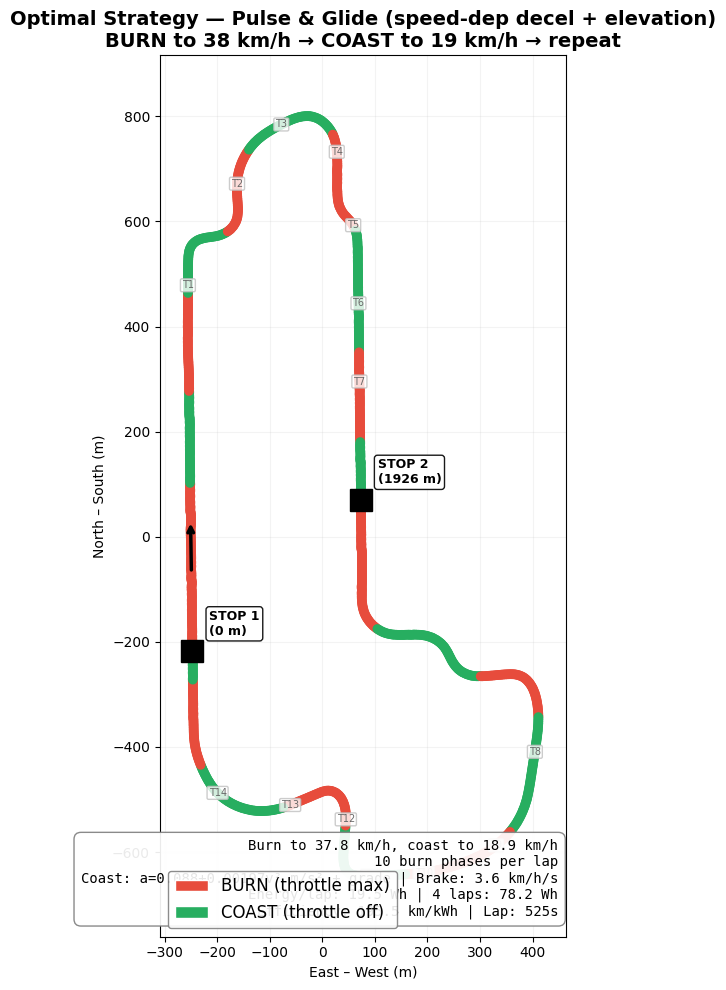

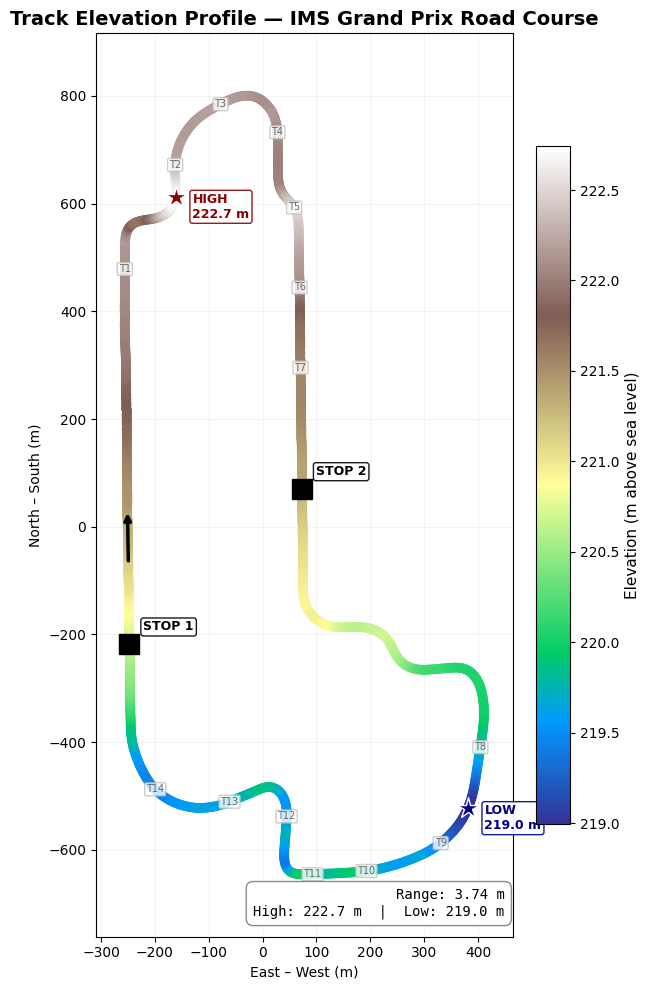

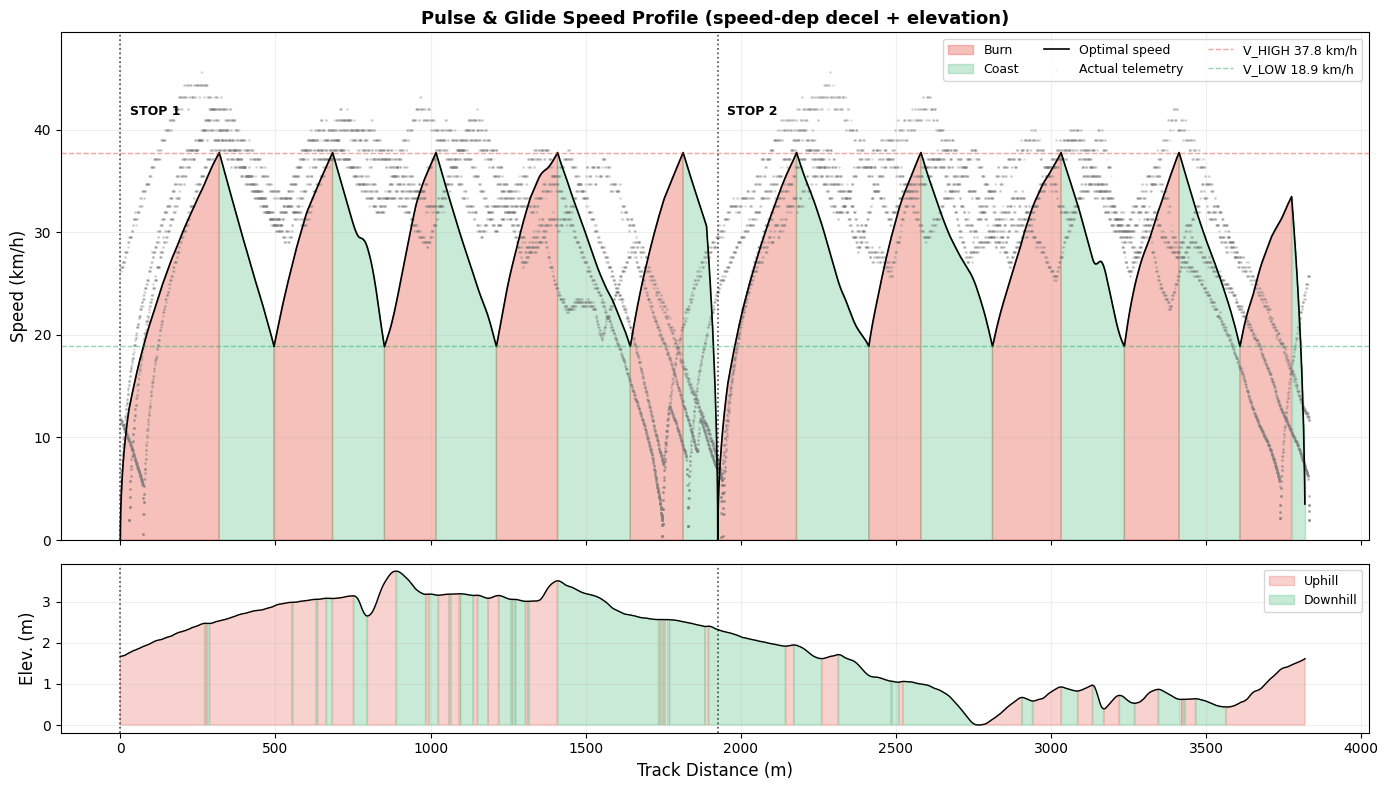

  PULSE & GLIDE STRATEGY (speed-dep decel + elevation)
  Vehicle:     164.0 kg | Max 45 km/h
  Accel 0–15s: 0.92 km/h/s (0.2556 m/s²)
  Accel 15s+:  0.70 km/h/s (0.1944 m/s²)
  Coast decel:  a = 0.0877 + 0.001970·v²  m/s²
    @20 km/h → 0.53 km/h/s  |  @35 km/h → 0.99 km/h/s
  Elevation:   ±g·sin(grade) applied at each step
  V_HIGH:      37.8 km/h | V_LOW: 18.9 km/h

  Seg 1 (1926m):  5 burn phases | 10.0 Wh | 264.2s
  Seg 2 (1893m):  5 burn phases | 9.5 Wh | 260.8s

  Lap time:    525.0s × 4 = 2100s  (budget: 2100s)
  Energy/lap:  19.5 Wh
  Total:       78.2 Wh over 15.3 km
  Efficiency:  195.5 km/kWh
-----------------------------------------------------------------
  Tune V_LOW_FRAC to trade cycle frequency vs energy.


In [343]:
# ── Energy-Optimal Driving Strategy ──
from matplotlib.patches import Patch

# ================================================================
# Section 1 — Map elevation from sem_2023_us.csv onto track distance
# ================================================================
elev_df = pd.read_csv('sem_2023_us.csv')
elev_lat = elev_df['Latitude'].values
elev_lon = elev_df['Longitude'].values
elev_raw_vals = elev_df['Metres above sea level'].values

nn_idx = np.empty(len(gps_lat), dtype=int)
CHUNK = 500
for start in range(0, len(gps_lat), CHUNK):
    end = min(start + CHUNK, len(gps_lat))
    dlat = gps_lat[start:end, None] - elev_lat[None, :]
    dlon = gps_lon[start:end, None] - elev_lon[None, :]
    nn_idx[start:end] = np.argmin(dlat**2 + dlon**2, axis=1)

elev_on_track_raw = elev_raw_vals[nn_idx]
elev_track_dist = arc / total_arc * TRACK_LEN
elev_smooth = pd.Series(elev_on_track_raw).rolling(21, center=True, min_periods=1).mean().values

def elev_at_d(d):
    return np.interp(d, elev_track_dist, elev_smooth)

# Precompute track grade (slope) for the simulation
_grade_N = 5000
_grade_d = np.linspace(0, TRACK_LEN, _grade_N)
_grade_elev = np.array([elev_at_d(d) for d in _grade_d])
_grade_vals = np.gradient(_grade_elev, _grade_d)  # dz/ds (dimensionless)

def grade_at_d(d):
    """Return track grade (rise/run) at distance d (mod TRACK_LEN)."""
    return np.interp(d % TRACK_LEN, _grade_d, _grade_vals)

print(f"Elevation mapped: {elev_smooth.min():.2f} – {elev_smooth.max():.2f} m "
      f"(range {elev_smooth.max() - elev_smooth.min():.2f} m)")
print(f"Grade range: {_grade_vals.min()*100:.2f}% to {_grade_vals.max()*100:.2f}%")

# ================================================================
# Section 2 — Physical constants & tuning parameters
# ================================================================
MASS_KG = (205 + 156.528) * 0.453592    # lbs → kg
G = 9.81
# Piecewise burn acceleration (from telemetry review):
#   0–15s of burning:   0.92 km/h/s
#   15s+ of burning:    0.70 km/h/s
A_ACC_1 = 0.92 / 3.6    # m/s² (first 15s of burn)
A_ACC_2 = 0.70 / 3.6    # m/s² (after 15s of burn)
T_ACC_BREAK = 15.0       # seconds — breakpoint

# Speed-dependent coast deceleration: a_dec = DEC_A + DEC_B * v²
# Fit from telemetry coast-down events (motor off, speed > 0.5 m/s)
_coast_mask = (df['Current_A'].abs() < 0.5) & (accel < -0.01) & (df['Speed_mps'] > 0.5)
_v_coast = df.loc[_coast_mask, 'Speed_mps'].values
_a_coast = -accel[_coast_mask].values   # positive magnitudes
_X = np.column_stack([np.ones_like(_v_coast), _v_coast**2])
_coeffs, *_ = np.linalg.lstsq(_X, _a_coast, rcond=None)
DEC_A = _coeffs[0]   # rolling-resistance term (m/s²)
DEC_B = _coeffs[1]   # aero-drag term (m/s² per (m/s)²)

V_MAX = 12.5              # m/s (45 km/h)
A_BRAKE = 1.0             # m/s² braking at mandatory stops (tune this)
N_LAPS = 4
TOTAL_TIME = 2100         # s (35 min)
TIME_PER_LAP = TOTAL_TIME / N_LAPS

HALF_1 = 1925.851
HALF_2 = 1893.020
STOP_POS = [0, HALF_1]
SEG_LENGTHS = [HALF_1, HALF_2]

V_LOW_FRAC = 0.50        # coast down to this fraction of V_HIGH before re-burning

print(f"Mass: {MASS_KG:.1f} kg")
print(f"Accel phase 1 (0–{T_ACC_BREAK:.0f}s): {A_ACC_1:.4f} m/s² ({A_ACC_1*3.6:.2f} km/h/s)")
print(f"Accel phase 2 ({T_ACC_BREAK:.0f}s+):  {A_ACC_2:.4f} m/s² ({A_ACC_2*3.6:.2f} km/h/s)")
print(f"Coast decel model: a = {DEC_A:.4f} + {DEC_B:.6f}·v²  (fit from {len(_v_coast)} coast pts)")
print(f"  at 20 km/h: {DEC_A + DEC_B*(20/3.6)**2:.4f} m/s² ({(DEC_A + DEC_B*(20/3.6)**2)*3.6:.2f} km/h/s)")
print(f"  at 35 km/h: {DEC_A + DEC_B*(35/3.6)**2:.4f} m/s² ({(DEC_A + DEC_B*(35/3.6)**2)*3.6:.2f} km/h/s)")
print(f"Brake at stops: {A_BRAKE:.2f} m/s² ({A_BRAKE*3.6:.2f} km/h/s)")
print(f"Seg 1: {HALF_1:.1f} m | Seg 2: {HALF_2:.1f} m")

# ================================================================
# Section 3 — Deceleration helpers
# ================================================================
def burn_accel(burn_elapsed):
    """Return current acceleration rate (m/s²) given time spent burning."""
    return A_ACC_1 if burn_elapsed < T_ACC_BREAK else A_ACC_2

def burn_distance(v_from, v_to):
    """Distance to accelerate from v_from to v_to with piecewise accel."""
    if v_from >= v_to:
        return 0.0
    # Time to reach v in phase 1 from 0: v / A_ACC_1
    # But we start from v_from, so track elapsed burn time
    d = 0.0
    v = v_from
    t_burn = 0.0
    dt_calc = 0.01
    while v < v_to:
        a = burn_accel(t_burn)
        v_new = min(v + a * dt_calc, v_to)
        d += (v + v_new) / 2 * dt_calc
        v = v_new
        t_burn += dt_calc
    return d

def coast_decel(v):
    """Return coast deceleration rate (m/s²) for current speed v."""
    return DEC_A + DEC_B * v**2

def braking_distance(v):
    """Distance to brake from speed v to 0 at mandatory stops."""
    return v**2 / (2 * A_BRAKE)

def braking_time(v):
    """Time to brake from speed v to 0."""
    return v / A_BRAKE

# ================================================================
# Section 4 — Simulate burn-coast cycling for one segment
# ================================================================
def simulate_segment(L, v_high, v_low, d_start=0.0, dt=0.05):
    """Simulate pulse-and-glide with piecewise accel, speed-dependent
    decel, and elevation (grade) effects.

    BURN:  accelerate at piecewise rate (adjusted for grade) until
           v_high or until stopping_distance(v) >= remaining distance.
    COAST: decelerate at a = DEC_A + DEC_B*v² (adjusted for grade)
           until v_low, then re-burn.

    d_start: absolute track position where this segment begins (m).
    """
    d, v, t = 0.0, 0.0, 0.0
    mode = 0  # 0=BURN, 1=COAST
    burn_elapsed = 0.0
    energy = 0.0

    ds, vs, ms = [0.0], [0.0], [0]

    while d < L - 0.5:
        remaining = L - d

        # Grade effect at current position: -g*sin(grade) ≈ -g*grade
        # Positive grade (uphill) → negative a_grade (slows car)
        # Negative grade (downhill) → positive a_grade (helps car)
        gr = grade_at_d(d_start + d)
        a_grade = -G * gr

        if mode == 0:  # BURN
            a_acc = burn_accel(burn_elapsed) + a_grade
            v_new = max(0, v + a_acc * dt)
            burn_elapsed += dt

            # Cap at v_high
            if v_new >= v_high:
                v_new = v_high
                mode = 1

            # Safety: must we start braking to stop in time?
            d_brake = braking_distance(v_new)
            if remaining - v_new * dt <= d_brake:
                mode = 1

            energy += 0.5 * MASS_KG * max(0, v_new**2 - v**2)
            v = v_new

        else:  # COAST
            a_dec = coast_decel(v) - a_grade  # grade offsets drag
            v_new = max(0, v - a_dec * dt)

            # Re-burn when speed drops to v_low, but NOT if we're
            # in the final braking approach
            d_brake_now = braking_distance(v_new)
            in_final_approach = (remaining < d_brake_now * 1.5 + 50)
            if v_new <= v_low and not in_final_approach:
                mode = 0
                burn_elapsed = 0.0

            # If within braking distance, apply brakes (faster decel)
            if remaining <= braking_distance(v_new) + v_new * dt:
                v_new = max(0, v_new - A_BRAKE * dt)  # brake hard

            v = v_new

        d += v * dt
        t += dt
        ds.append(d)
        vs.append(v)
        ms.append(mode)

        if v <= 0.001 and mode == 1 and remaining < 5.0:
            break
        if t > 3000:
            break

    n_burns = sum(1 for i in range(1, len(ms)) if ms[i] == 0 and ms[i-1] == 1) + (1 if ms[0] == 0 else 0)
    return np.array(ds), np.array(vs), np.array(ms, dtype=int), energy, t, n_burns

seg_starts = [0, HALF_1]

# Binary search for V_HIGH that meets the time budget
v_lo_search, v_hi_search = 1.0, V_MAX
for _ in range(80):
    v_mid = (v_lo_search + v_hi_search) / 2
    v_low_test = v_mid * V_LOW_FRAC
    t_total = 0
    for j, L in enumerate(SEG_LENGTHS):
        _, _, _, _, t_seg, _ = simulate_segment(L, v_mid, v_low_test,
                                                d_start=seg_starts[j])
        t_total += t_seg
    if t_total > TIME_PER_LAP:
        v_lo_search = v_mid
    else:
        v_hi_search = v_mid
V_HIGH = v_hi_search
V_LOW = V_HIGH * V_LOW_FRAC

print(f"\nOptimal V_HIGH: {V_HIGH:.2f} m/s ({V_HIGH*3.6:.1f} km/h)")
print(f"Coast to V_LOW: {V_LOW:.2f} m/s ({V_LOW*3.6:.1f} km/h)")
print(f"Braking dist from V_HIGH: {braking_distance(V_HIGH):.0f} m "
      f"({braking_time(V_HIGH):.1f}s)")

# ================================================================
# Section 5 — Run full simulation, build combined profile
# ================================================================
all_d, all_v, all_m = [], [], []
total_energy = 0
seg_info = []

for i, L in enumerate(SEG_LENGTHS):
    ds, vs, ms, energy, t_seg, n_burns = simulate_segment(
        L, V_HIGH, V_LOW, d_start=seg_starts[i])
    ds_offset = ds + seg_starts[i]
    all_d.append(ds_offset)
    all_v.append(vs)
    all_m.append(ms)
    total_energy += energy
    seg_info.append((L, t_seg, energy, n_burns))
    print(f"  Seg {i+1} ({L:.0f}m): {t_seg:.1f}s | {n_burns} burns | {energy/3600:.2f} Wh")

d_profile = np.concatenate(all_d)
v_profile = np.concatenate(all_v)
m_profile = np.concatenate(all_m)

lap_time = sum(si[1] for si in seg_info)
energy_per_lap = total_energy
energy_4laps = energy_per_lap * N_LAPS
dist_total_km = (HALF_1 + HALF_2) * N_LAPS / 1000
eff_km_kwh = dist_total_km / (energy_4laps / 3.6e6) if energy_4laps > 0 else float('inf')

print(f"\nLap time: {lap_time:.1f}s × {N_LAPS} = {lap_time*N_LAPS:.0f}s (budget {TOTAL_TIME}s)")
print(f"Energy/lap: {energy_per_lap/3600:.1f} Wh | 4 laps: {energy_4laps/3600:.1f} Wh")
print(f"Efficiency: {eff_km_kwh:.1f} km/kWh")

# ================================================================
# Section 6 — Track map colored by zone (BURN / COAST)
# ================================================================
ZONE_COLORS = ['#E74C3C', '#27AE60']
ZONE_NAMES  = ['BURN (throttle max)', 'COAST (throttle off)']
zone_cmap = plt.matplotlib.colors.ListedColormap(ZONE_COLORS)
zone_norm = plt.matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5], zone_cmap.N)

N_MAP = 1000
map_dists = np.linspace(0, HALF_1 + HALF_2, N_MAP)
map_xy = np.array([dist_to_xy(d % TRACK_LEN) for d in map_dists])
map_pts = map_xy.reshape(-1, 1, 2)
map_segs = np.concatenate([map_pts[:-1], map_pts[1:]], axis=1)

map_zones = np.interp(map_dists, d_profile, m_profile.astype(float))
map_zones = np.round(map_zones).astype(int)

_turn_info = [
    ('T1',  700), ('T2',  950), ('T3', 1100), ('T4', 1250),
    ('T5', 1400), ('T6', 1550), ('T7', 1700),
    ('T8', 2650), ('T9', 2850), ('T10', 3000),
    ('T11', 3100), ('T12', 3250), ('T13', 3400), ('T14', 3550),
]

fig_map, ax_map = plt.subplots(1, 1, figsize=(12, 10))

lc = LineCollection(map_segs, cmap=zone_cmap, norm=zone_norm,
                    linewidths=7, capstyle='round')
lc.set_array(map_zones[:-1].astype(float))
ax_map.add_collection(lc)

for j, sp in enumerate(STOP_POS):
    sxy = dist_to_xy(sp % TRACK_LEN)
    ax_map.plot(*sxy, 's', color='black', ms=16, zorder=6)
    ax_map.annotate(f'STOP {j+1}\n({sp:.0f} m)', sxy, textcoords='offset points',
                    xytext=(12, 12), fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='black', alpha=0.9))

a1, a2 = dist_to_xy(150), dist_to_xy(250)
ax_map.annotate('', xy=a2, xytext=a1,
                arrowprops=dict(arrowstyle='->', color='black', lw=2.5))

for lbl, d in _turn_info:
    txy = dist_to_xy(d)
    ax_map.annotate(lbl, txy, fontsize=7, ha='center', va='center',
                    color='dimgray',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='silver', alpha=0.8))

legend_patches = [Patch(facecolor=c, edgecolor='white', label=n)
                  for c, n in zip(ZONE_COLORS, ZONE_NAMES)]
ax_map.legend(handles=legend_patches, loc='lower left', fontsize=12,
              framealpha=0.9, edgecolor='grey')

n_burns_total = sum(si[3] for si in seg_info)
stats_text = (
    f"Burn to {V_HIGH*3.6:.1f} km/h, coast to {V_LOW*3.6:.1f} km/h\n"
    f"{n_burns_total} burn phases per lap\n"
    f"Coast: a={DEC_A:.3f}+{DEC_B:.5f}v² m/s² + grade | "
    f"Brake: {A_BRAKE*3.6:.1f} km/h/s\n"
    f"Energy/lap: {energy_per_lap/3600:.1f} Wh | 4 laps: {energy_4laps/3600:.1f} Wh\n"
    f"Efficiency: {eff_km_kwh:.1f} km/kWh | Lap: {lap_time:.0f}s"
)
ax_map.text(0.98, 0.02, stats_text, transform=ax_map.transAxes,
            fontsize=10, verticalalignment='bottom', horizontalalignment='right',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      alpha=0.92, edgecolor='grey'))

ax_map.set_aspect('equal')
ax_map.set_title('Optimal Strategy — Pulse & Glide (speed-dep decel + elevation)\n'
                 f'BURN to {V_HIGH*3.6:.0f} km/h → COAST to {V_LOW*3.6:.0f} km/h → repeat',
                 fontsize=14, fontweight='bold')
ax_map.set_xlabel('East – West (m)')
ax_map.set_ylabel('North – South (m)')
ax_map.grid(True, alpha=0.15)
ax_map.autoscale()
ax_map.margins(0.08)
plt.tight_layout()
plt.show()

# ================================================================
# Section 6b — Elevation profile on track map
# ================================================================
elev_map_vals = np.array([elev_at_d(d % TRACK_LEN) for d in map_dists])

fig_elev_map, ax_em = plt.subplots(1, 1, figsize=(12, 10))

norm_elev = Normalize(vmin=elev_map_vals.min(), vmax=elev_map_vals.max())
lc_elev = LineCollection(map_segs, cmap='terrain', norm=norm_elev,
                         linewidths=7, capstyle='round')
lc_elev.set_array(elev_map_vals[:-1])
ax_em.add_collection(lc_elev)

cbar = fig_elev_map.colorbar(lc_elev, ax=ax_em, shrink=0.75, pad=0.02)
cbar.set_label('Elevation (m above sea level)', fontsize=11)

for j, sp in enumerate(STOP_POS):
    sxy = dist_to_xy(sp % TRACK_LEN)
    ax_em.plot(*sxy, 's', color='black', ms=14, zorder=6)
    ax_em.annotate(f'STOP {j+1}', sxy, textcoords='offset points',
                   xytext=(10, 10), fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', alpha=0.9))

i_hi = np.argmax(elev_map_vals)
i_lo = np.argmin(elev_map_vals)
for idx, label, color in [(i_hi, 'HIGH', '#8B0000'), (i_lo, 'LOW', '#00008B')]:
    xy = map_xy[idx]
    val = elev_map_vals[idx]
    ax_em.plot(*xy, '*', color=color, ms=16, zorder=7, markeredgecolor='white', markeredgewidth=1)
    ax_em.annotate(f'{label}\n{val:.1f} m', xy, textcoords='offset points',
                   xytext=(12, -15), fontsize=9, fontweight='bold', color=color,
                   bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.9))

a1, a2 = dist_to_xy(150), dist_to_xy(250)
ax_em.annotate('', xy=a2, xytext=a1,
               arrowprops=dict(arrowstyle='->', color='black', lw=2.5))

for lbl, d in _turn_info:
    txy = dist_to_xy(d)
    ax_em.annotate(lbl, txy, fontsize=7, ha='center', va='center',
                   color='dimgray',
                   bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='silver', alpha=0.8))

ax_em.text(0.98, 0.02,
           f'Range: {elev_map_vals.max() - elev_map_vals.min():.2f} m\n'
           f'High: {elev_map_vals.max():.1f} m  |  Low: {elev_map_vals.min():.1f} m',
           transform=ax_em.transAxes, fontsize=10,
           verticalalignment='bottom', horizontalalignment='right', family='monospace',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.92, edgecolor='grey'))

ax_em.set_aspect('equal')
ax_em.set_title('Track Elevation Profile — IMS Grand Prix Road Course',
                fontsize=14, fontweight='bold')
ax_em.set_xlabel('East – West (m)')
ax_em.set_ylabel('North – South (m)')
ax_em.grid(True, alpha=0.15)
ax_em.autoscale()
ax_em.margins(0.08)
plt.tight_layout()
plt.show()

# ================================================================
# Section 7 — Speed profile + elevation (stacked figure)
# ================================================================
fig_prof, (ax_spd, ax_elev) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]})

burn_mask = m_profile == 0
coast_mask = m_profile == 1

ax_spd.fill_between(d_profile, 0, v_profile * 3.6, where=burn_mask,
                    color='#E74C3C', alpha=0.35, label='Burn', step='mid')
ax_spd.fill_between(d_profile, 0, v_profile * 3.6, where=coast_mask,
                    color='#27AE60', alpha=0.25, label='Coast', step='mid')
ax_spd.plot(d_profile, v_profile * 3.6, 'k-', linewidth=1.2, label='Optimal speed')

ax_spd.scatter(df['TrackPos'].values, df['Speed_kph'].values,
               s=1, alpha=0.08, color='grey', label='Actual telemetry', rasterized=True)

ax_spd.axhline(V_HIGH * 3.6, color='#E74C3C', ls='--', lw=1, alpha=0.5,
               label=f'V_HIGH {V_HIGH*3.6:.1f} km/h')
ax_spd.axhline(V_LOW * 3.6, color='#27AE60', ls='--', lw=1, alpha=0.5,
               label=f'V_LOW {V_LOW*3.6:.1f} km/h')

for j, sp in enumerate(STOP_POS):
    ax_spd.axvline(sp, color='black', ls=':', lw=1.2, alpha=0.7)
    ax_spd.text(sp + 30, V_MAX * 3.6 * 0.92, f'STOP {j+1}', fontsize=9, fontweight='bold')

ax_spd.set_ylabel('Speed (km/h)', fontsize=12)
ax_spd.set_ylim(0, V_MAX * 3.6 * 1.1)
ax_spd.legend(loc='upper right', fontsize=9, ncol=3)
ax_spd.grid(True, alpha=0.2)
ax_spd.set_title('Pulse & Glide Speed Profile (speed-dep decel + elevation)', fontsize=13, fontweight='bold')

d_elev = np.linspace(0, HALF_1 + HALF_2, 2000)
elev_plot = elev_at_d(d_elev % TRACK_LEN)
elev_rel = elev_plot - elev_plot.min()
grade_plot = np.gradient(elev_plot, d_elev)

ax_elev.fill_between(d_elev, 0, elev_rel, where=grade_plot >= 0,
                     color='#E74C3C', alpha=0.25, label='Uphill')
ax_elev.fill_between(d_elev, 0, elev_rel, where=grade_plot < 0,
                     color='#27AE60', alpha=0.25, label='Downhill')
ax_elev.plot(d_elev, elev_rel, 'k-', linewidth=1)

for j, sp in enumerate(STOP_POS):
    ax_elev.axvline(sp, color='black', ls=':', lw=1.2, alpha=0.7)

ax_elev.set_xlabel('Track Distance (m)', fontsize=12)
ax_elev.set_ylabel('Elev. (m)', fontsize=12)
ax_elev.legend(loc='upper right', fontsize=9)
ax_elev.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ================================================================
# Summary
# ================================================================
print("=" * 65)
print("  PULSE & GLIDE STRATEGY (speed-dep decel + elevation)")
print("=" * 65)
print(f"  Vehicle:     {MASS_KG:.1f} kg | Max {V_MAX*3.6:.0f} km/h")
print(f"  Accel 0–{T_ACC_BREAK:.0f}s: {A_ACC_1*3.6:.2f} km/h/s ({A_ACC_1:.4f} m/s²)"
      f"\n  Accel {T_ACC_BREAK:.0f}s+:  {A_ACC_2*3.6:.2f} km/h/s ({A_ACC_2:.4f} m/s²)")
print(f"  Coast decel:  a = {DEC_A:.4f} + {DEC_B:.6f}·v²  m/s²")
print(f"    @20 km/h → {coast_decel(20/3.6)*3.6:.2f} km/h/s  |  "
      f"@35 km/h → {coast_decel(35/3.6)*3.6:.2f} km/h/s")
print(f"  Elevation:   ±g·sin(grade) applied at each step")
print(f"  V_HIGH:      {V_HIGH*3.6:.1f} km/h | V_LOW: {V_LOW*3.6:.1f} km/h")
print(f"")
for i, (L, t_seg, e_seg, nb) in enumerate(seg_info):
    print(f"  Seg {i+1} ({L:.0f}m):  {nb} burn phases | {e_seg/3600:.1f} Wh | {t_seg:.1f}s")
print(f"")
print(f"  Lap time:    {lap_time:.1f}s × {N_LAPS} = {lap_time*N_LAPS:.0f}s  (budget: {TOTAL_TIME}s)")
print(f"  Energy/lap:  {energy_per_lap/3600:.1f} Wh")
print(f"  Total:       {energy_4laps/3600:.1f} Wh over {dist_total_km:.1f} km")
print(f"  Efficiency:  {eff_km_kwh:.1f} km/kWh")
print("-" * 65)
print("  Tune V_LOW_FRAC to trade cycle frequency vs energy.")
print("=" * 65)